In [1]:
import pandas as pd
import numpy as np
import datetime as dt 
import yfinance as yf

In [2]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2023,1,1)
stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2013-01-01,175.208511,176.438125,174.875054,175.896266,6831351
2013-01-02,176.719452,178.397143,175.594054,175.896250,13441898
2013-01-03,179.387054,179.647557,176.021266,176.854888,17266808
2013-01-04,179.616302,180.189422,177.886525,179.626723,13306377
2013-01-07,178.522171,181.523242,177.521814,180.418684,15307180
...,...,...,...,...,...
2022-12-26,1146.917358,1155.073774,1132.535760,1142.691556,5990242
2022-12-27,1156.300781,1158.163745,1142.918812,1149.621155,5763271


In [4]:
#dataset=stk_data[['Close']].copy()
#dataset.columns

In [5]:
column="Close"

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (2468, 1)


In [7]:
len(data1)

2468

In [8]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1974
X_train length: (1974, 1)
X_test length: (494, 1)
y_train length: (1974, 1)
y_test length: (494, 1)


In [9]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        print(y_pred.shape)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

(494,)
Lag=1,Trend=n
RMSE-Testset: 0.10465498418487205
MAPE: 0.09768599236349856
************
(494,)
Lag=1,Trend=t
RMSE-Testset: 0.1065938135302567
MAPE: 0.10306571961163062
************
(494,)
Lag=1,Trend=c
RMSE-Testset: 0.06096178695635503
MAPE: 0.058713012586339944
************
(494,)
Lag=1,Trend=ct
RMSE-Testset: 0.10466311140220061
MAPE: 0.10073639725576512
************
(494,)
Lag=2,Trend=n
RMSE-Testset: 0.10641535006121888
MAPE: 0.09916273276905319
************
(494,)
Lag=2,Trend=t
RMSE-Testset: 0.1047275023344558
MAPE: 0.10101000835034903
************
(494,)
Lag=2,Trend=c
RMSE-Testset: 0.06131682130071865
MAPE: 0.05938544874624131
************
(494,)
Lag=2,Trend=ct
RMSE-Testset: 0.10323952067930126
MAPE: 0.09913944521763614
************
(494,)
Lag=3,Trend=n
RMSE-Testset: 0.10190555045989985
MAPE: 0.09537789926768013
************
(494,)
Lag=3,Trend=t
RMSE-Testset: 0.11022189233052597
MAPE: 0.10705675804870933
************
(494,)
Lag=3,Trend=c
RMSE-Testset: 0.06075256600160271
MAPE

In [10]:
len(y_pred)

494

In [17]:
i=1
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=ct
RMSE-Testset: 0.10466311140220061
MAPE: 0.10073639725576512
************


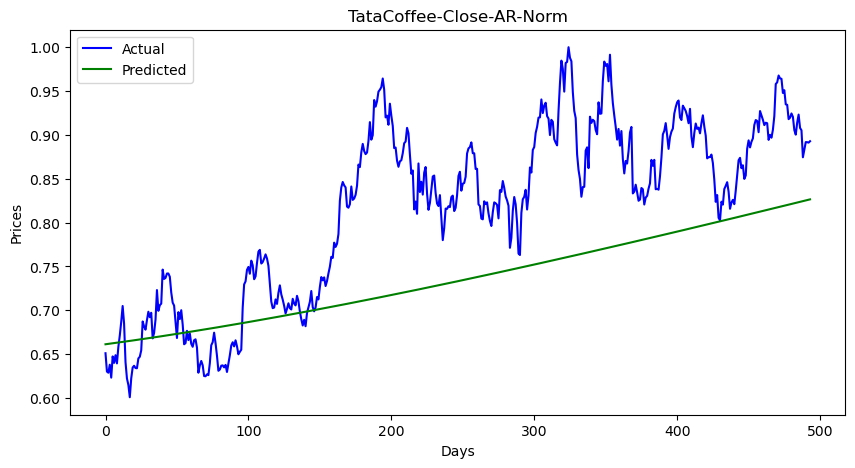

In [19]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [13]:
len(data1)

2468

In [14]:
y_test

array([[0.65111585],
       [0.63016864],
       [0.6289163 ],
       [0.63802636],
       [0.62330064],
       [0.64745974],
       [0.64008677],
       [0.64889389],
       [0.63954132],
       [0.65832727],
       [0.67143697],
       [0.68691001],
       [0.70496875],
       [0.68484966],
       [0.64097558],
       [0.62239167],
       [0.61493795],
       [0.60095965],
       [0.62251289],
       [0.63483479],
       [0.63679424],
       [0.63422876],
       [0.63400657],
       [0.6451973 ],
       [0.64709611],
       [0.65442865],
       [0.68731401],
       [0.68161766],
       [0.67798171],
       [0.68884924],
       [0.69844416],
       [0.69216204],
       [0.69725236],
       [0.66808374],
       [0.67428512],
       [0.68945517],
       [0.72312833],
       [0.69947431],
       [0.70589782],
       [0.70763497],
       [0.74645915],
       [0.73585429],
       [0.73700567],
       [0.74201519],
       [0.74199503],
       [0.7383186 ],
       [0.72040141],
       [0.708

In [20]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [21]:
aTestNormTable

,Close
0,0.651116
1,0.630169
2,0.628916
3,0.638026
4,0.623301
...,...
489,0.88342
490,0.891819
491,0.891717
492,0.891249


In [22]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [23]:
actual_stock_price_test_ori

array([[ 887.38824463],
       [ 863.98608398],
       [ 862.5869751 ],
       [ 872.76470947],
       [ 856.31317139],
       [ 883.3036499 ],
       [ 875.06658936],
       [ 884.90588379],
       [ 874.45721436],
       [ 895.44482422],
       [ 910.09094238],
       [ 927.37738037],
       [ 947.55255127],
       [ 925.07556152],
       [ 876.05957031],
       [ 855.29766846],
       [ 846.97039795],
       [ 831.35388184],
       [ 855.43310547],
       [ 869.19909668],
       [ 871.38818359],
       [ 868.52203369],
       [ 868.27380371],
       [ 880.77606201],
       [ 882.8973999 ],
       [ 891.08929443],
       [ 927.82873535],
       [ 921.46478271],
       [ 917.40270996],
       [ 929.54388428],
       [ 940.26330566],
       [ 933.24493408],
       [ 938.93182373],
       [ 906.34472656],
       [ 913.27288818],
       [ 930.2208252 ],
       [ 967.84039307],
       [ 941.41418457],
       [ 948.59051514],
       [ 950.53125   ],
       [ 993.90551758],
       [ 982.057

In [24]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [25]:
actual_stock_price_test_oriA

,Close
0,887.388245
1,863.986084
2,862.586975
3,872.764709
4,856.313171
...,...
489,1146.917358
490,1156.300781
491,1156.187134
492,1155.664551


In [26]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [27]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

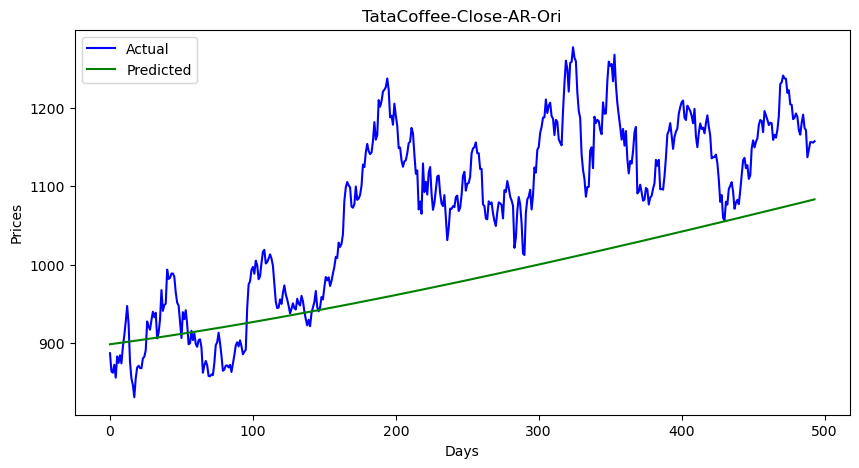

In [28]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [29]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 116.92933548221393
MAPE: 0.0862836500864461


In [30]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [31]:
forecast

array([0.82693824, 0.82734113, 0.82774417, 0.82814735])

In [32]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [33]:
forecast_stock_price_test_oriF

,Closefore
0,1083.816533
1,1084.266643
2,1084.716915
3,1085.167348


In [34]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

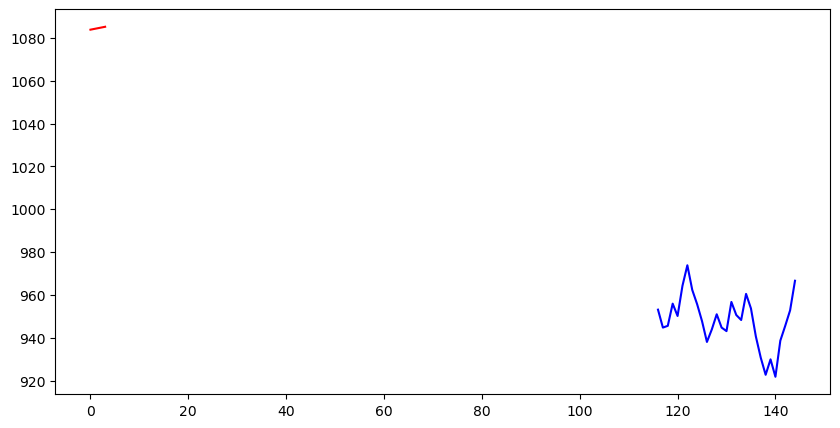

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")

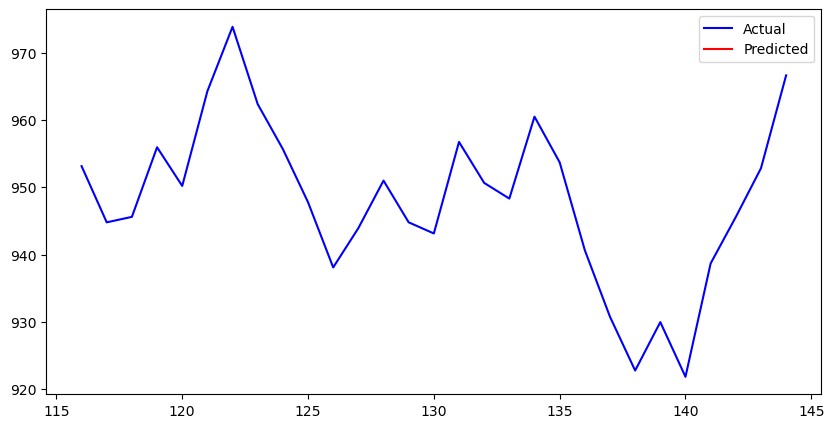

In [39]:
plt.figure(figsize=(10,5))

plt.plot(actual_stock_price_test_oriA[116:145], color='blue', label='Actual')
plt.plot(forecast_stock_price_test_oriF[116:145], color='red', label='Predicted')

plt.legend()
plt.show()

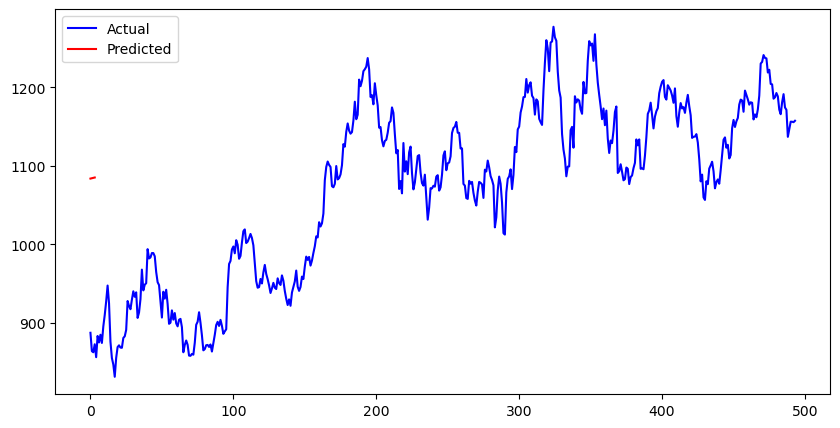

In [42]:
plt.figure(figsize=(10,5))

plt.plot(actual_stock_price_test_oriA,
         color='blue',
         label='Actual')

plt.plot(forecast_stock_price_test_oriF,
         color='red',
         label='Predicted')

plt.legend()
plt.show()

In [43]:
print(actual_stock_price_test_oriA.shape)
print(forecast_stock_price_test_oriF.shape)

(494, 1)
(4, 1)


In [44]:
print(actual_stock_price_test_oriA[:10])
print(forecast_stock_price_test_oriF[:10])

        Close
0  887.388245
1  863.986084
2  862.586975
3  872.764709
4  856.313171
5   883.30365
6  875.066589
7  884.905884
8  874.457214
9  895.444824
     Closefore
0  1083.816533
1  1084.266643
2  1084.716915
3  1085.167348


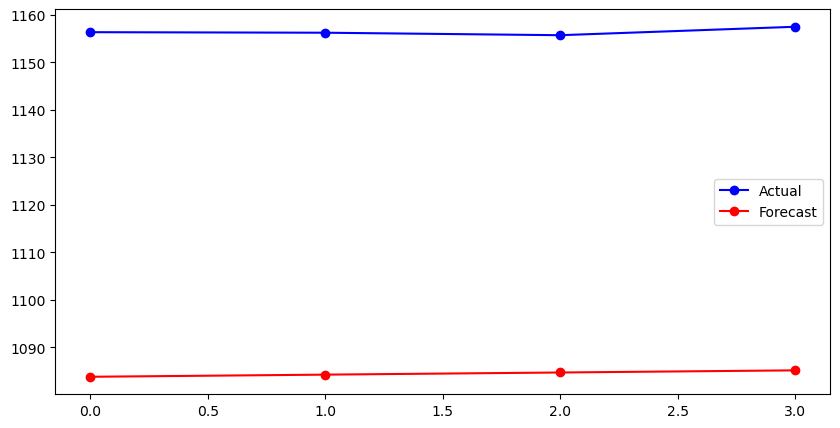

In [46]:
plt.figure(figsize=(10,5))

plt.plot(range(4),
         actual_stock_price_test_oriA[-4:],
         color='blue',
         marker='o',
         label='Actual')

plt.plot(range(4),
         forecast_stock_price_test_oriF,
         color='red',
         marker='o',
         label='Forecast')

plt.legend()
plt.show()